# 1주차. 데이터셋 고찰 — BDG2 해부

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RAW_DIR = "../Data/raw/bdg2"
CANDIDATES_PATH = "../Data/raw/lead_labeled_candidates.csv"

## 과제 1-1. 데이터 로드와 구조 파악

In [3]:
meta = pd.read_csv(f"{RAW_DIR}/metadata.csv", encoding="utf-8")
meta.shape

(1636, 32)

In [4]:
meta.head()

,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


In [5]:
site_counts = meta['site_id'].value_counts()
print("site별 건물 수")
print(site_counts)

site별 건물 수
site_id
Rat         305
Hog         163
Lamb        147
Fox         137
Panther     136
Cockatoo    124
Bull        124
Eagle       106
Bear         92
Gator        74
Robin        52
Peacock      47
Bobcat       36
Wolf         36
Swan         21
Moose        15
Shrew         9
Mouse         7
Crow          5
Name: count, dtype: int64


In [6]:
primaryspaceusage_counts = meta['primaryspaceusage'].value_counts()
print("용도별 건물 수")
print(primaryspaceusage_counts)

용도별 건물 수
primaryspaceusage
Education                        617
Office                           307
Entertainment/public assembly    204
Lodging/residential              168
Public services                  166
Other                             29
Healthcare                        29
Parking                           24
Warehouse/storage                 15
Manufacturing/industrial          13
Retail                            12
Services                          11
Technology/science                 7
Food sales and service             6
Utility                            4
Religious worship                  3
Name: count, dtype: int64


electricity.csv`의 shape, 기간, 시간 간격을 확인한다.

In [7]:
electricity = pd.read_csv(f"{RAW_DIR}/meters/electricity.csv", encoding="utf-8")
electricity.shape

(17544, 1579)

In [8]:
print("기간:", electricity["timestamp"].min(), "~", electricity["timestamp"].max())

기간: 2016-01-01 00:00:00 ~ 2017-12-31 23:00:00


In [9]:
ts = pd.to_datetime(electricity["timestamp"])
interval = ts.diff().dropna().unique()
print("시간 간격 (고유값):", interval)

시간 간격 (고유값): <TimedeltaArray>
['0 days 01:00:00']
Length: 1, dtype: timedelta64[ns]


## 과제 1-2. 분석 대상 서브셋 선정

In [10]:
label = pd.read_csv("../Data/raw/lead_labeled_candidates.csv", encoding="utf-8")
label.shape

(200, 7)

In [11]:
print(label["site_id"].value_counts())

site_id
Bull        52
Eagle       47
Lamb        24
Fox         21
Robin       16
Rat         11
Hog         11
Panther      8
Gator        3
Bear         2
Bobcat       2
Cockatoo     1
Moose        1
Wolf         1
Name: count, dtype: int64


In [12]:
print(label["primaryspaceusage"].value_counts())

primaryspaceusage
Education                        80
Office                           62
Entertainment/public assembly    23
Lodging/residential              13
Public services                   7
Healthcare                        5
Services                          3
Manufacturing/industrial          2
Parking                           2
Other                             1
Food sales and service            1
Religious worship                 1
Name: count, dtype: int64


In [13]:
print("결측 개수:")
print(label.isna().sum())

결측 개수:
building_id                0
site_id                    0
kaggle_id                  0
primaryspaceusage          0
sub_primaryspaceusage      0
sqm                        0
yearbuilt                133
dtype: int64


In [14]:
print(label["sqm"].describe())

count      200.00000
mean      9887.10050
std       9549.13448
min         83.40000
25%       2952.50000
50%       6592.65000
75%      12865.35000
max      45000.00000
Name: sqm, dtype: float64


In [15]:
elec_cols = electricity.columns
matched = label["building_id"].isin(elec_cols).sum()
print(matched)

200


In [17]:
meter_types = ["electricity", "chilledwater", "steam", "hotwater", "gas", "water", "irrigation", "solar"]

meta = pd.read_csv(f"{RAW_DIR}/metadata.csv", encoding="utf-8").set_index("building_id")

meters = {}
for m in meter_types:
    df = pd.read_csv(f"{RAW_DIR}/meters/{m}.csv", encoding="utf-8")
    meters[m] = df.set_index("timestamp")

results = []
for bid in label["building_id"]:
    owned = [m for m in meter_types if meta.loc[bid, m] == "Yes"]
    total_missing = 0
    total_rows = 0
    found_meters = []
    for m in owned:
        if bid in meters[m].columns:
            s = meters[m][bid]
            total_missing += s.isna().sum()
            total_rows += len(s)
            found_meters.append(m)
    rate = total_missing / total_rows if total_rows > 0 else None
    results.append({
        "building_id": bid,
        "n_meters": len(found_meters),
        "meters": ",".join(found_meters),
        "total_rows": total_rows,
        "total_missing": total_missing,
        "missing_rate": rate,
    })

res = pd.DataFrame(results).set_index("building_id")

print("전체 200개 결측률 통계:")
print(res["missing_rate"].describe())

print("결측률 0인 건물 수:", (res["missing_rate"] == 0).sum())

print("미터 개수 분포:")
print(res["n_meters"].value_counts().sort_index())

전체 200개 결측률 통계:
count    200.000000
mean       0.013376
std        0.050741
min        0.000000
25%        0.000000
50%        0.000883
75%        0.001978
max        0.441746
Name: missing_rate, dtype: float64
결측률 0인 건물 수: 56
미터 개수 분포:
n_meters
1    53
2    44
3    94
4     9
Name: count, dtype: int64


In [18]:
STUCK_THRESHOLD = 72  

def stuck_mask(values, min_len=2):
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        j = i
        while j + 1 < n and values[j + 1] == values[i]:
            j += 1
        if j - i + 1 >= min_len:
            mask[i:j + 1] = True
        i = j + 1
    return mask

def longest_true_run(mask):
    max_run, cur = 0, 0
    for v in mask:
        if v:
            cur += 1
            max_run = max(max_run, cur)
        else:
            cur = 0
    return max_run

profile_rows = []
for bid in label["building_id"]:
    owned = [m for m in meter_types if meta.loc[bid, m] == "Yes"]
    nan_total, rows_total, worst_run = 0, 0, 0
    for m in owned:
        if bid in meters[m].columns:
            s = meters[m][bid]
            values = s.fillna(-999999).values
            combined = stuck_mask(values, min_len=2) | s.isna().values
            worst_run = max(worst_run, longest_true_run(combined))
            nan_total += int(s.isna().sum())
            rows_total += len(s)
    profile_rows.append({
        "building_id": bid,
        "max_run_hours": worst_run,
        "nan_rate": nan_total / rows_total if rows_total > 0 else 1.0,
    })

profile = pd.DataFrame(profile_rows).set_index("building_id")

extreme = profile[profile["max_run_hours"] >= STUCK_THRESHOLD]
survived = profile[profile["max_run_hours"] < STUCK_THRESHOLD]

print(f"72시간 이상 구간이 하나라도 있어 탈락: {len(extreme)}개")
print(f"통과(72시간 이상 구간 전혀 없음): {len(survived)}개")

72시간 이상 구간이 하나라도 있어 탈락: 183개
통과(72시간 이상 구간 전혀 없음): 17개


In [19]:
subset = label[label["building_id"].isin(survived.index)].copy()
subset = subset.merge(survived[["nan_rate", "max_run_hours"]], left_on="building_id", right_index=True)
subset = subset.sort_values("nan_rate").reset_index(drop=True)

print(f"최종 서브셋: {len(subset)}개 건물")
print(subset[["building_id", "site_id", "primaryspaceusage", "sqm", "nan_rate", "max_run_hours"]].to_string())

최종 서브셋: 17개 건물
               building_id site_id              primaryspaceusage      sqm  nan_rate  max_run_hours
0   Hog_parking_Antoinette     Hog                        Parking   1949.7  0.000000             19
1         Fox_office_Vicki     Fox                         Office   6580.5  0.000057              7
2           Fox_office_Joy     Fox                         Office   6581.0  0.000114              7
3    Hog_services_Marshall     Hog                       Services   6506.9  0.000342             49
4         Bull_office_Ella    Bull                         Office    821.0  0.000399             23
5     Fox_education_Elvira     Fox                      Education  13826.7  0.000684             46
6        Bull_office_Sally    Bull                         Office   7705.3  0.000741             26
7    Fox_education_Charles     Fox                      Education    909.3  0.000912              4
8      Bear_education_Chad    Bear                      Education  39101.5  0.001425 

In [21]:
print("용도별 분포")
print(subset["primaryspaceusage"].value_counts())

용도별 분포
primaryspaceusage
Office                           8
Education                        4
Entertainment/public assembly    2
Parking                          1
Services                         1
Public services                  1
Name: count, dtype: int64


In [22]:
print("사이트별 분포")
print(subset["site_id"].value_counts())

사이트별 분포
site_id
Rat     7
Fox     4
Hog     2
Bull    2
Bear    2
Name: count, dtype: int64


In [23]:
print("면적 분포")
print(subset["sqm"].describe())

면적 분포
count       17.000000
mean      9638.788235
std      12179.563907
min         83.400000
25%        909.300000
50%       6506.900000
75%       9754.800000
max      39101.500000
Name: sqm, dtype: float64


In [24]:
subset_out_path = "../Data/raw/subset_17_buildings.csv"
subset[["building_id", "site_id", "primaryspaceusage", "sub_primaryspaceusage", "sqm", "yearbuilt", "nan_rate", "max_run_hours"]].to_csv(
    subset_out_path, index=False, encoding="utf-8"
)
print(f"저장 완료: {subset_out_path}")

저장 완료: ../Data/raw/subset_17_buildings.csv


## 과제 1-3. 결측 프로파일링

In [25]:
CONTINUOUS_THRESHOLD = 48  #연속 결측 기준: 2일(48시간)

def runs_in_mask(mask, min_len=1):
    n = len(mask)
    runs = []
    i = 0
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            run_len = j - i + 1
            if run_len >= min_len:
                runs.append(run_len)
            i = j + 1
        else:
            i += 1
    return runs

profile_rows = []
for bid in subset["building_id"]:
    owned = [m for m in meter_types if meta.loc[bid, m] == "Yes"]
    nan_total, rows_total = 0, 0
    structural_missing = []
    all_runs = []
    for m in owned:
        if bid not in meters[m].columns:
            structural_missing.append(m)
            continue
        s = meters[m][bid]
        rows_total += len(s)
        nan_total += int(s.isna().sum())
        values = s.fillna(-999999).values
        combined = stuck_mask(values, min_len=2) | s.isna().values  # NaN과 고정값을 합쳐서 정확한 연속 길이 계산
        all_runs.extend(runs_in_mask(combined, min_len=2))

    max_run = max(all_runs) if all_runs else 0
    n_sporadic = sum(1 for r in all_runs if r < CONTINUOUS_THRESHOLD)
    sporadic_hours = sum(r for r in all_runs if r < CONTINUOUS_THRESHOLD)
    n_continuous = sum(1 for r in all_runs if r >= CONTINUOUS_THRESHOLD)
    continuous_hours = sum(r for r in all_runs if r >= CONTINUOUS_THRESHOLD)

    if structural_missing:
        gtype = "구조적"
    elif n_continuous > 0:
        gtype = "연속"
    elif n_sporadic > 0 or nan_total > 0:
        gtype = "산발적"
    else:
        gtype = "없음"

    row = subset.loc[subset["building_id"] == bid].iloc[0]
    profile_rows.append({
        "building_id": bid,
        "site_id": row["site_id"],
        "usage": row["primaryspaceusage"],
        "NaN개수": nan_total,
        "NaN비율(%)": round(nan_total / rows_total * 100, 4) if rows_total else None,
        "산발적구간수": n_sporadic,
        "산발적총시간": sporadic_hours,
        "연속구간수": n_continuous,
        "연속총시간": continuous_hours,
        "최장연속(시간)": max_run,
        "구조적결측미터": ",".join(structural_missing) if structural_missing else "-",
        "유형": gtype,
    })

missing_profile = pd.DataFrame(profile_rows).sort_values("최장연속(시간)", ascending=False)

print(missing_profile.to_string(index=False))
print("\n유형별 건물 수:")
print(missing_profile["유형"].value_counts())

import os
os.makedirs("../results/wk1", exist_ok=True)
profile_out_path = "../results/wk1/wk01_missing_profile.csv"
missing_profile.to_csv(profile_out_path, index=False, encoding="utf-8")
print(f"\n저장 완료: {profile_out_path}")

           building_id site_id                         usage  NaN개수  NaN비율(%)  산발적구간수  산발적총시간  연속구간수  연속총시간  최장연속(시간) 구조적결측미터  유형
 Hog_services_Marshall     Hog                      Services      6    0.0342      20      89      1     49        49       -  연속
      Rat_office_Craig     Rat                        Office    124    0.7068      24     114      1     48        48       -  연속
  Fox_education_Elvira     Fox                     Education     24    0.0684      57     189      0      0        46       - 산발적
  Bear_education_Lewis    Bear                     Education     39    0.2223    1469    4688      0      0        37       - 산발적
  Rat_assembly_Pauline     Rat Entertainment/public assembly     76    0.4332    2015    6926      0      0        30       - 산발적
   Rat_assembly_Kelley     Rat Entertainment/public assembly     28    0.1596    1494    4276      0      0        27       - 산발적
   Rat_public_Julieann     Rat               Public services     28    0.1596    2136   10

## 과제 1-4. 결측 처리 3안 비교

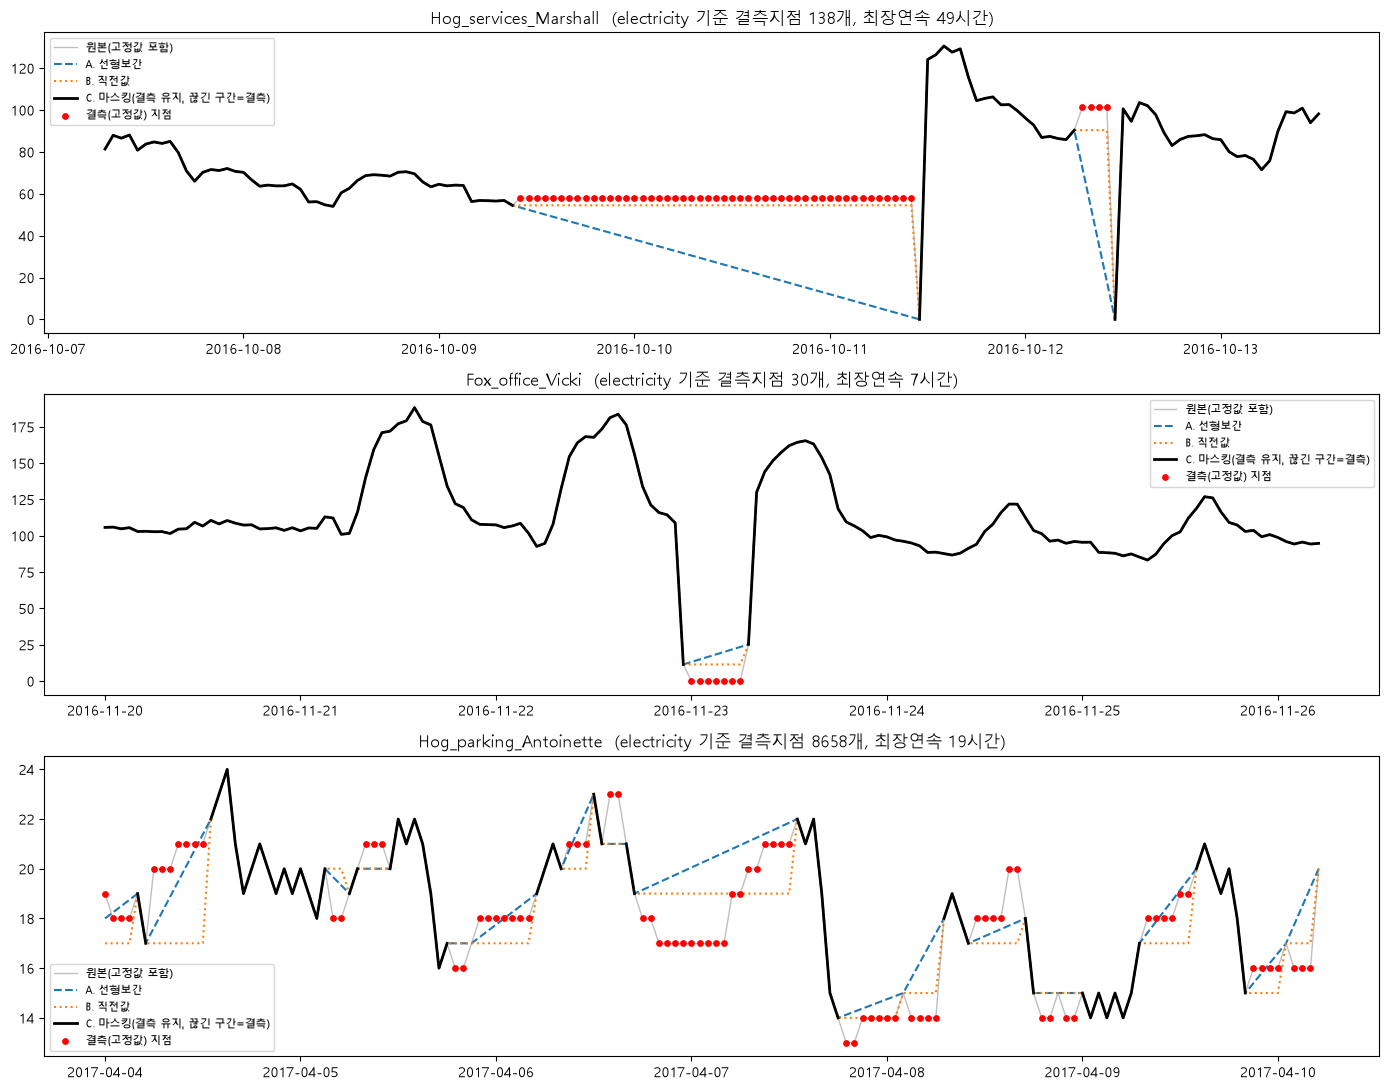

A(선형보간) vs B(직전값)이 실제로 다른 값을 낸 지점 수 (electricity 기준):
              building_id  결측지점수  A_B_다른지점
0   Hog_services_Marshall    138       138
1        Fox_office_Vicki     30        30
2  Hog_parking_Antoinette   8658      6988


In [26]:
plt.rcParams["font.family"] = "Malgun Gothic"  
plt.rcParams["axes.unicode_minus"] = False     

def stuck_mask(values, min_len=2):
    n = len(values)
    mask = np.zeros(n, dtype=bool)
    i = 0
    while i < n:
        j = i
        while j + 1 < n and values[j + 1] == values[i]:
            j += 1
        if j - i + 1 >= min_len:
            mask[i:j + 1] = True
        i = j + 1
    return mask

def longest_run_start(mask):
    n = len(mask)
    best_start, best_len = 0, 0
    i = 0
    while i < n:
        if mask[i]:
            j = i
            while j + 1 < n and mask[j + 1]:
                j += 1
            run_len = j - i + 1
            if run_len > best_len:
                best_len, best_start = run_len, i
            i = j + 1
        else:
            i += 1
    return best_start, best_len

# 새 17개 서브셋 기준 대표 3건: 연속 유형 1건(Marshall) + 산발적 낮음/높음 2건
representative = ["Hog_services_Marshall", "Fox_office_Vicki", "Hog_parking_Antoinette"]

ts_full = pd.to_datetime(electricity["timestamp"])
fig, axes = plt.subplots(len(representative), 1, figsize=(14, 11))

diff_summary = []
for ax, bid in zip(axes, representative):
    s = electricity[bid]
    values = s.fillna(-999999).values
    mask = stuck_mask(values, min_len=2) | s.isna().values

    masked = s.copy()
    masked[mask] = np.nan          # C. 마스킹

    method_a = masked.interpolate(method="linear")   # A. 선형 보간
    method_b = masked.ffill()                          # B. 직전값 채우기

    diff_ab = (method_a[mask] != method_b[mask]).sum()
    diff_summary.append({"building_id": bid, "결측지점수": int(mask.sum()), "A_B_다른지점": int(diff_ab)})


    run_start, run_len = longest_run_start(mask)
    center = run_start + run_len // 2
    lo, hi = max(0, center - 75), min(len(s), center + 75)
    idx = slice(lo, hi)

    ax.plot(ts_full[idx], s.values[idx], color="0.75", linewidth=1, label="원본(고정값 포함)")
    ax.plot(ts_full[idx], method_a.values[idx], "--", label="A. 선형보간")
    ax.plot(ts_full[idx], method_b.values[idx], ":", label="B. 직전값")
    ax.plot(ts_full[idx], masked.values[idx], "-", color="black", linewidth=2, label="C. 마스킹(결측 유지, 끊긴 구간=결측)")
    gap_idx = np.where(mask[idx])[0]
    if len(gap_idx) > 0:
        gap_times = ts_full[idx].values[gap_idx]
        gap_vals = s.values[idx][gap_idx]
        ax.scatter(gap_times, gap_vals, color="red", s=15, zorder=5, label="결측(고정값) 지점")
    ax.set_title(f"{bid}  (electricity 기준 결측지점 {int(mask.sum())}개, 최장연속 {run_len}시간)")
    ax.legend(fontsize=8)

plt.tight_layout()

import os
os.makedirs("../results/wk1", exist_ok=True)
plt.savefig("../results/wk1/wk01_imputation_comparison.png", dpi=110)
plt.show()

print("A(선형보간) vs B(직전값)이 실제로 다른 값을 낸 지점 수 (electricity 기준):")
print(pd.DataFrame(diff_summary))

### 결측 처리 방식 선택 근거

세 방식을 유형별 대표 사례(연속 1건, 산발적 2건)에 적용해 비교한 결과, **유형에 따라 서로 다른 방식을 적용하는 것으로 결정한다.** 연속 유형(`Hog_services_Marshall`)의 경우 49시간에 달하는 구간을 A(선형보간)는 57에서 0까지 떨어졌다가 되돌아오는 비현실적인 급락 구간으로, B(직전값)는 이틀간 완전히 평평한 직선으로 채우는데, 실제 건물 전력 소비가 이 시간 동안 이런 패턴을 보였을 가능성은 낮으므로 두 방식 모두 근거 없는 값을 만들어낼 뿐이다. 따라서 연속 결측은 **C(마스킹 후 평가 제외)**를 적용해, 이 구간이 예측·평가에 개입하지 않도록 한다. 반면 산발적 유형(`Fox_office_Vicki`, `Hog_parking_Antoinette`)은 결측 지점이 2~19시간 내외로 짧고 전후 실측값이 존재하므로, B(직전값)가 만드는 계단식 평탄 구간보다 실제 추세를 매끄럽게 따라가는 **A(선형보간)**가 더 타당하다. 이는 1주차 배경 개념의 결측 유형별 처리 원칙("산발적 → 보간 또는 직전값 OK, 연속 → 마스킹 후 제외")과도 일치하는 결론이다.

## 과제 1-5. 기본 EDA

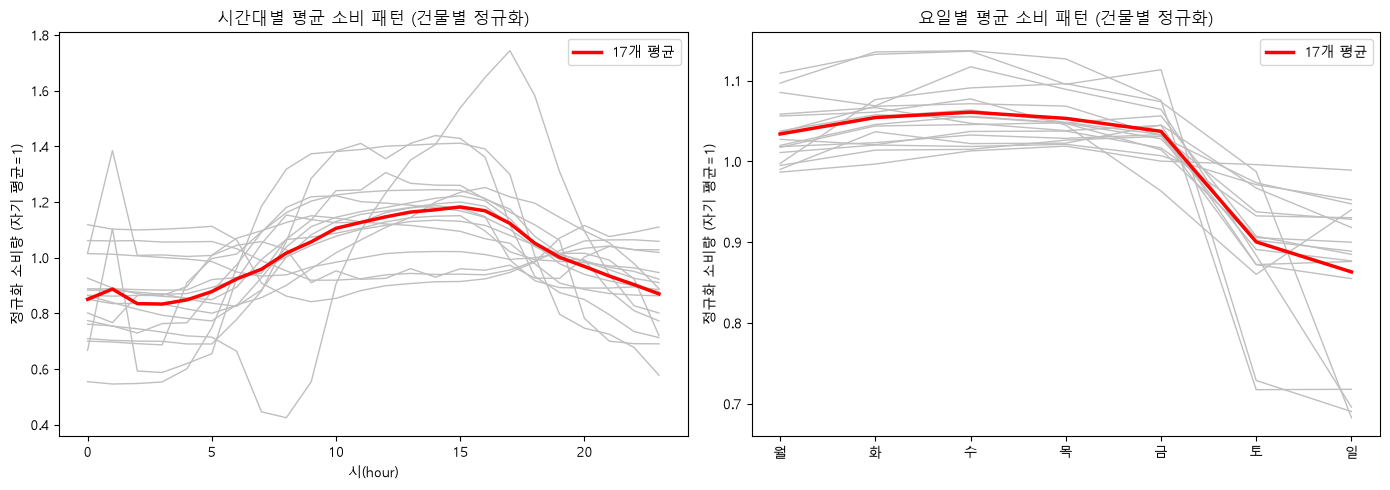

In [27]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

weather = pd.read_csv(f"{RAW_DIR}/weather.csv", encoding="utf-8")
weather["timestamp"] = pd.to_datetime(weather["timestamp"])

ts_full = pd.to_datetime(electricity["timestamp"])
electricity_idx = electricity.set_index(ts_full)

# ===== 1) 시간대별 / 요일별 평균 (건물마다 규모가 달라 자기 평균으로 정규화 후 비교) =====
hourly_profiles, weekday_profiles = [], []
for bid in subset["building_id"]:
    s = electricity_idx[bid]
    norm = s / s.mean()
    hourly_profiles.append(norm.groupby(norm.index.hour).mean().rename(bid))
    weekday_profiles.append(norm.groupby(norm.index.dayofweek).mean().rename(bid))

hourly_df = pd.concat(hourly_profiles, axis=1)
weekday_df = pd.concat(weekday_profiles, axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(hourly_df.index, hourly_df.values, color="0.75", linewidth=1)
axes[0].plot(hourly_df.index, hourly_df.mean(axis=1), color="red", linewidth=2.5, label="17개 평균")
axes[0].set_title("시간대별 평균 소비 패턴 (건물별 정규화)")
axes[0].set_xlabel("시(hour)")
axes[0].set_ylabel("정규화 소비량 (자기 평균=1)")
axes[0].legend()

weekday_labels = ["월", "화", "수", "목", "금", "토", "일"]
axes[1].plot(weekday_df.index, weekday_df.values, color="0.75", linewidth=1)
axes[1].plot(weekday_df.index, weekday_df.mean(axis=1), color="red", linewidth=2.5, label="17개 평균")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(weekday_labels)
axes[1].set_title("요일별 평균 소비 패턴 (건물별 정규화)")
axes[1].set_ylabel("정규화 소비량 (자기 평균=1)")
axes[1].legend()

plt.tight_layout()
import os
os.makedirs("../results/wk1", exist_ok=True)
plt.savefig("../results/wk1/wk01_hourly_weekday_pattern.png", dpi=110)
plt.show()

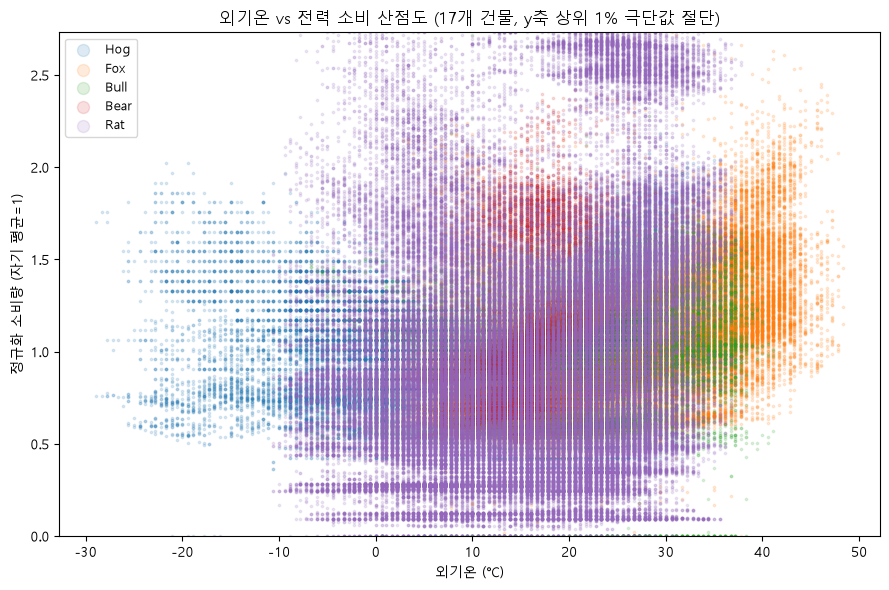

In [28]:
# ===== 2) 외기온 vs 소비 산점도 (사이트별 색상 구분) =====
fig, ax = plt.subplots(figsize=(9, 6))
colors = plt.cm.tab10.colors
site_list = subset["site_id"].unique().tolist()

all_norm_vals = []
for i, site in enumerate(site_list):
    site_weather = weather[weather["site_id"] == site].set_index("timestamp")["airTemperature"]
    site_buildings = subset.loc[subset["site_id"] == site, "building_id"]
    first = True
    for bid in site_buildings:
        s = electricity_idx[bid]
        norm = s / s.mean()
        merged = pd.concat([norm.rename("consumption"), site_weather], axis=1, join="inner").dropna()
        all_norm_vals.append(merged["consumption"])
        ax.scatter(
            merged["airTemperature"], merged["consumption"],
            s=3, alpha=0.15, color=colors[i % 10],
            label=site if first else None,
        )
        first = False

# 극단값 몇 개가 스케일을 다 눌러버려서, 대부분 점이 몰린 범위(0~99th 백분위)로 y축을 제한
y_upper = pd.concat(all_norm_vals).quantile(0.99)
ax.set_ylim(0, y_upper)
ax.set_xlabel("외기온 (°C)")
ax.set_ylabel("정규화 소비량 (자기 평균=1)")
ax.set_title(f"외기온 vs 전력 소비 산점도 (17개 건물, y축 상위 1% 극단값 절단)")
ax.legend(markerscale=5, fontsize=9)
plt.tight_layout()
plt.savefig("../results/wk1/wk01_temp_vs_consumption.png", dpi=110)
plt.show()